In [1]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from datetime import datetime
from utils import tabulate_neatly
import SPDE
import yaml
import time

# Flags

Runs experiment for those which are set to true

In [2]:
HEAT = True
NAGUMO = True
ALLEN_CAHN = True
KDV = True
BURGERS = True

DRIFT = True
DIFFUSION = True

RANDOM_INITIAL_CONDITIONS = True
GENERATE_PREDICTION_DATA = True
GENERATE_TRAINING_DATA = True

SHOW_U_DISTRIBUTION = False
UPDATE_PARAMETERS = True
DO_SMOOTHNESS_ANALYSIS = True
DO_UXX_UXXXX_CORR = False 
DO_HEATMAPS = True
DO_TEMPORAL_CORR_DIAGNOSTIC = False
EQUAL_SIZE_CONFIGS = {(3, 6), (6, 3)}


LEGENDRE_POLYNOMIALS = False
IDENTIFICATION_TASKS = {"Drift": DRIFT, "Diffusion": DIFFUSION}

#### Generate Data

In [3]:
import DataGenerator as dg

experimentKeys = {"Heat": HEAT,
 "Nagumo": NAGUMO,
 "Allen_Cahn": ALLEN_CAHN,
 "KdV": KDV,
 "Burgers": BURGERS
 }

for key, value in experimentKeys.items():
    if value and GENERATE_TRAINING_DATA:
        dg.generateData(key, randomConditions=RANDOM_INITIAL_CONDITIONS)

with open("parameters.yaml") as f:
    yamlParameters = yaml.safe_load(f)

space = yamlParameters["common"]["x_end"] - yamlParameters["common"]["x_start"]
timeRange = yamlParameters["common"]["t_end"] - yamlParameters["common"]["t_start"]
timeSteps = yamlParameters["common"]["timesteps"]
spacePoints = yamlParameters["common"]["J"]
isPeriodic = yamlParameters["common"]["periodic"]
dt = timeRange / timeSteps
dx = space / spacePoints

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Sample number:  0
Sample number:  100
Sample number:  200
Sample number:  300
Sample number:  400
Sample number:  500
Sample number:  600
Sample number:  700
Sample number:  800
Sample number:  900
Sample number:  1000
Sample number:  1100
Sample number:  1200
Sample number:  1300
Sample number:  1400
Sample number:  1500
Sample number:  1600
Sample number:  1700
Sample number:  1800
Sample number:  1900
uStorage shape: (64, 501, 2000)
xdt shape: (64, 500)
xdiff shape: (64, 500)
Sample number:  0
Sample number:  100
Sample number:  200
Sample number:  300
Sample number:  400
Sample number:  500
Sample number:  600
Sample number:  700
Sample number:  800
Sample number:  900
Sample number:  1000
Sample number:  1100
Sample number:  1200
Sample number:  1300
Sample number:  1400
Sample number:  1500
Sample number:  1600
Sample number:  1700
Sample number:  1800
Sample number: 

## Intermission - Dynamics and Empirical Distributions

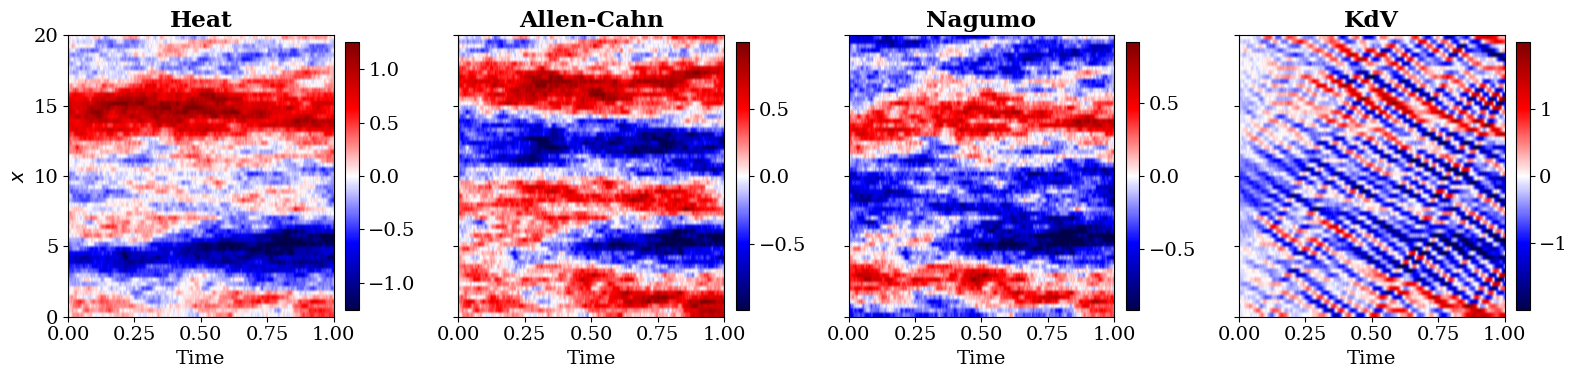

In [73]:
sampleIDX = 0
keys        = ["Heat", "Allen_Cahn", "Nagumo", "KdV"]
titles      = ["Heat", "Allen-Cahn", "Nagumo", "KdV"]

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"]   = 14

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, key, title in zip(axes, keys, titles):
    U = np.load(f"data/{key}_dx_{spacePoints}m_{timeSteps}t.npy")
    u = U[:, :, sampleIDX]          # shape (64, 501)

    vmax = np.percentile(np.abs(u), 99)

    im = ax.imshow(
        u,
        cmap="seismic",
        aspect="auto",
        origin="lower",
        extent=[0, 1, 0, 20],        # time on x-axis, space on y-axis
        vmin=-vmax,
        vmax=vmax,
    )
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Time")
    if ax is axes[0]:
        ax.set_ylabel("$x$")
    else:
        ax.set_yticklabels([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("worthwhileImages/dynamics_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [5]:
indices = [451, 745]

if SHOW_U_DISTRIBUTION:
    for index in indices:
        colors = {'Heat': 'steelblue', 'Nagumo': 'darkorange', 'Allen_Cahn': 'green', 'KdV': 'purple'}
        fig, axes = plt.subplots(1, len([k for k, v in experimentKeys.items() if v]), figsize=(5 * sum(experimentKeys.values()), 4))
        axes = np.atleast_1d(axes)
        for ax, key in zip(axes, [k for k, v in experimentKeys.items() if v]):
            U = np.load(f'data/{key}_dx_{spacePoints}m_{timeSteps}t.npy')
            
            normalised_vals = []
            # for s in range(U.shape[2]):
            u_traj = U[:, :-1, index]
            umin, umax = u_traj.min(), u_traj.max()
            if not np.isclose(umin, umax):
                u_scaled = 2 * (u_traj - umin) / (umax - umin) - 1
                normalised_vals.append(u_scaled.flatten())

            normalised_vals = np.concatenate(normalised_vals)
            ax.hist(normalised_vals, bins=100, color=colors[key], alpha=0.8, density=True)
            ax.set_title(key.replace('_', ' '), fontweight='bold')
            ax.set_xlabel('Normalised u value')
            ax.set_ylabel('Density')
            ax.set_xlim(-1, 1)
            ax.grid(color='gray', linestyle='--', linewidth=0.5)

        plt.suptitle('Distribution of per-trajectory $\\tilde{u}$ values. Index: ' + str(index), fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'worthwhileImages/u_value_histograms_index_{index}.pdf', dpi=150, bbox_inches='tight')
        plt.show()

### Configurations

In [6]:
DICT_CONFIGS = [(6, 6), (3, 6), (6, 3), (3, 3)]
activeProblems = [key for key, value in experimentKeys.items() if value]

RUN_CONFIGS = [
    {problem: problem, "D": d, "P": p}
    for problem in activeProblems
    for d, p in DICT_CONFIGS
]

In [7]:
dataCache = {}
dictCache = {}

#### Mean of Dictionaries

In [8]:
for config in RUN_CONFIGS:
    problem, D, P = config.values()
    if problem == "Burgers" and (D, P) in EQUAL_SIZE_CONFIGS:
        continue
    if problem not in dataCache:
        xdt_raw   = np.load(f"data/{problem}_xdt_{spacePoints}m_{timeSteps}t.npy")
        xdiff_raw = np.load(f"data/{problem}_xdiff_{spacePoints}m_{timeSteps}t.npy")
        dataCache[problem] = (xdt_raw, xdiff_raw)

    if (problem, D, P) not in dictCache:
        print(f"Building dictionary: {problem} D={D} P={P}...")
        U = np.load(f"data/{problem}_dx_{spacePoints}m_{timeSteps}t.npy")
        Dictt = []
        for i in range(U.shape[2]):
            if i % 500 == 0:
                print(f"  sample {i}/{U.shape[2]}")
            _, Di, desc = SPDE.build_linear_system(U[:, :-1, i], dt, dx, D=D, P=P,periodic=isPeriodic, legendre=False)
            Dictt.append(Di)
        dictCache[(problem, D, P)] = (np.mean(np.array(Dictt), axis=0), desc)

problemDictionaries = {p: dictCache[(p, 6, 6)][0] for p in activeProblems}
problemDescriptions  = {p: dictCache[(p, 6, 6)][1] for p in activeProblems}

Building dictionary: Heat D=6 P=6...
  sample 0/2000
  sample 500/2000
  sample 1000/2000
  sample 1500/2000
Building dictionary: Heat D=3 P=6...
  sample 0/2000
  sample 500/2000
  sample 1000/2000
  sample 1500/2000
Building dictionary: Heat D=6 P=3...
  sample 0/2000
  sample 500/2000
  sample 1000/2000
  sample 1500/2000
Building dictionary: Heat D=3 P=3...
  sample 0/2000
  sample 500/2000
  sample 1000/2000
  sample 1500/2000
Building dictionary: Nagumo D=6 P=6...
  sample 0/2000
  sample 500/2000
  sample 1000/2000
  sample 1500/2000
Building dictionary: Nagumo D=3 P=6...
  sample 0/2000
  sample 500/2000
  sample 1000/2000
  sample 1500/2000
Building dictionary: Nagumo D=6 P=3...
  sample 0/2000
  sample 500/2000
  sample 1000/2000
  sample 1500/2000
Building dictionary: Nagumo D=3 P=3...
  sample 0/2000
  sample 500/2000
  sample 1000/2000
  sample 1500/2000
Building dictionary: Allen_Cahn D=6 P=6...
  sample 0/2000
  sample 500/2000
  sample 1000/2000
  sample 1500/2000
Build

# Targets

In [9]:
#mildly accurate

if not LEGENDRE_POLYNOMIALS:
    TRUE_PDE_DRIFT = {
        "Heat":       {"u_xx": "epsilon"},
        "Allen_Cahn": {"u_xx": "epsilon", "u": "u_coeff", "u^3": "u3_coeff"},
        "Nagumo":     {"u_xx": "epsilon", "u": "u_coeff", "u^2": "u2_coeff", "u^3": "u3_coeff"},
        "KdV":        {"uu_x": "uu_x_coeff", "u_xxx": "u_xxx_coeff"},
        "Burgers":    {"uu_x": "uu_x_coeff", "u_xx": "epsilon"},
    }
    TRUE_PDE_DIFFUSION = {
        "Heat":       {"1": "sigma"},
        "Allen_Cahn": {"1": "sigma"},
        "Nagumo":     {"1": "sigma"},
        "KdV":        {"1": "sigma"},
        "Burgers":    {"1": "sigma", "u": "u_coeff", "u^2": "u2_coeff"},
    }
else:
    # NOTE: definitely inaccurate wrt expansions but just needed something to make the rest run 
    TRUE_PDE_DRIFT = {
        "Heat":       {"P0(u)u_xx": "epsilon"},
        "Allen_Cahn": {"P0(u)u_xx": "epsilon", "P1(u)": "u_coeff", "P3(u)": "u3_coeff"},
        "Nagumo":     {"P0(u)u_xx": "epsilon", "P1(u)": "u_coeff", "P2(u)": "u2_coeff", "P3(u)": "u3_coeff"},
        "KdV":        {"P1(u)u_x": "uu_x_coeff", "P0(u)u_xxx": "u_xxx_coeff"},
        "Burgers":    {"P1(u)u_x": "uu_x_coeff", "P0(u)u_xx": "epsilon"},
    }
    TRUE_PDE_DIFFUSION = {
        "Heat":       {"P0(u)": "sigma"},
        "Allen_Cahn": {"P0(u)": "sigma"},
        "Nagumo":     {"P0(u)": "sigma"},
        "KdV":        {"P0(u)": "sigma"},
        "Burgers":    {"P0(u)": "sigma", "P1(u)": "u_coeff", "P2(u)": "u2_coeff"},
    }

def buildTrueCoeffs(problem, description, yaml_params, term_map, drift=True):
    if term_map is None:
        print(f"Warning: true coefficients for {problem} undefined in Legendre basis")
        return None
    coeffs = np.zeros(len(description))
    if problem == "Burgers" and not drift:
        for term in ["1", "u", "u^2"]: # hardcoded to cater for expansinon
            if term not in description:
                print(f"Warning: '{term}' not in dictionary for Burgers diffusion. Increase D or P")
                return None
        coeffs[description.index("1")] = 1
        coeffs[description.index("u")] = 2
        coeffs[description.index("u^2")] = 1
        return coeffs
    params = yaml_params[problem.lower()]["correct"]["drift" if drift else "diffusion"]
    for label, yaml_key in term_map.items():
        if label not in description:
            print(f"Warning: '{label}' not in dictionary for {problem}. Increase D or P")
            continue
        coeffs[description.index(label)] = params[yaml_key]
    return coeffs

### Algorithm Helpers and Record Keeping

In [ ]:
def getAlgorithms():
    def runSINDy(Theta, y, task):
        lam = yamlParameters["common"][f"sindy_{task.lower()}_lambda"]
        np.random.seed(0)
        Xi = SPDE.stridge(lam, Theta, y.reshape(1, -1, order="F"))
        return Xi.reshape(-1), None

    def runVBAlg2(Theta, y, task):
        np.random.seed(30)
        DS = SPDE.ormerodAlgorithm2(Theta, y, tol=1e-6, verbosity=False, p0=0.1, vs=100)
        return DS["wmean"].copy(), DS

    def runVBAlg1(Theta, y, task):
        np.random.seed(30)
        DS = SPDE.Variational_Bayes_Code(
            Theta, y, np.ones(Theta.shape[1]), tol=1e-6, verbosity=False, p0=0.1, vs=100
        )
        return DS["wmean"].copy(), DS
    
    return [("SINDy", runSINDy), ("VB_Alg2", runVBAlg2), ("VB_Alg1", runVBAlg1)]

def extractRecords(problem, D, P, algorithm, task, description, Xi_flat, DS, yamlParams):
    trueTermMap = TRUE_PDE_DRIFT[problem] if task == "Drift" else TRUE_PDE_DIFFUSION[problem]
    trueCoeffs  = buildTrueCoeffs(
        problem, description, yamlParams, trueTermMap, drift=(task == "Drift")
    )
    if trueCoeffs is None:
        trueCoeffs = np.zeros(len(description))

    records = []
    for i, label in enumerate(description):
        term = label if label != "" else "1"
        est  = float(Xi_flat[i])
        pip  = float(DS["zmean"][i]) if DS is not None else None

        isSelected = (est != 0.0) if DS is None else (pip > 0.5 and est != 0.0)
        if not isSelected:
            continue

        trueVal    = float(trueCoeffs[i]) if trueCoeffs[i] != 0 else None
        isTrueTerm = trueVal is not None
        relErrPct  = round((est - trueVal) / abs(trueVal) * 100, 1) if isTrueTerm else None
        variance   = float(np.diag(DS["wCOV"])[i]) if DS is not None else None

        records.append({
            "problem":       problem,
            "D":             D,
            "P":             P,
            "algorithm":     algorithm,
            "task":          task,
            "term":          term,
            "true_value":    trueVal,
            "estimated":     round(est, 6),
            "rel_error_pct": relErrPct,
            "variance":      variance,
            "pip":           pip,
            "is_true_term":  isTrueTerm,
        })
    return records

In [60]:
allResults = []
problemDS = {}

## Sweep

In [ ]:
for cfg in RUN_CONFIGS:
    problem, D, P = cfg.values()
    if problem == "Burgers" and (D, P) in EQUAL_SIZE_CONFIGS:
        continue
    Theta, desc  = dictCache[(problem, D, P)]
    xdt, xdiff = dataCache[problem]

    for task, target in [("Drift", xdt), ("Diffusion", xdiff)]:
        y = target.reshape(-1, order="F")

        for algName, algFn in getAlgorithms():
            if algName == "VB_Alg2" and (D, P) in EQUAL_SIZE_CONFIGS:
                continue

            print(f"{problem} | D={D} P={P} | {algName} | {task}")
            start_time = time.time()
            Xi_flat, DS = algFn(Theta, y, task)
            end_time = time.time()
            print(f"  Time taken to run {algName} for problem {problem} and task {task}: {end_time - start_time:.2f} seconds")

            allResults += extractRecords(
                problem, D, P, algName, task, desc, Xi_flat, DS, yamlParameters
            )

            if D == 3 and P == 3 and algName == "VB_Alg2" and DS is not None:
                problemDS.setdefault(problem, {})[task] = DS

Heat | D=6 P=6 | SINDy | Drift
  Time taken to run SINDy for problem Heat and task Drift: 0.03 seconds
Heat | D=6 P=6 | SINDy | Diffusion
  Time taken to run SINDy for problem Heat and task Diffusion: 0.02 seconds
Heat | D=3 P=6 | SINDy | Drift
  Time taken to run SINDy for problem Heat and task Drift: 0.02 seconds
Heat | D=3 P=6 | SINDy | Diffusion
  Time taken to run SINDy for problem Heat and task Diffusion: 0.02 seconds
Heat | D=6 P=3 | SINDy | Drift
  Time taken to run SINDy for problem Heat and task Drift: 0.02 seconds
Heat | D=6 P=3 | SINDy | Diffusion
  Time taken to run SINDy for problem Heat and task Diffusion: 0.02 seconds
Heat | D=3 P=3 | SINDy | Drift
  Time taken to run SINDy for problem Heat and task Drift: 0.01 seconds
Heat | D=3 P=3 | SINDy | Diffusion
  Time taken to run SINDy for problem Heat and task Diffusion: 0.01 seconds
Nagumo | D=6 P=6 | SINDy | Drift
  Time taken to run SINDy for problem Nagumo and task Drift: 0.03 seconds
Nagumo | D=6 P=6 | SINDy | Diffusion


In [62]:
df = pd.DataFrame(allResults)
print(f"{len(df)} records - {df['problem'].nunique()} problems, "
      f"{df['algorithm'].nunique()} algorithms, "
      f"{df[['D','P']].drop_duplicates().shape[0]} dict configs")

85 records - 5 problems, 1 algorithms, 4 dict configs


## Tabulation

In [59]:
os.makedirs("results", exist_ok=True)
stamp = datetime.now().strftime("%Y%m%d_%H%M")
df.to_csv(f"results/results_{stamp}.csv", index=False)
df.to_csv("results/results_latest.csv",   index=False)
print(f"Saved {len(df)} records : results/results_{stamp}.csv")

Saved 103 records : results/results_20260819_1242.csv


In [ ]:
legCache = {}

### Legendre, just for comparison

In [35]:
for problem in activeProblems:
    print(f"Building Legendre dictionary: {problem} D=6 P=6...")
    U = np.load(f"data/{problem}_dx_{spacePoints}m_{timeSteps}t.npy")
    Dictt = []
    if legCache.get(problem) is None:
        for i in range(U.shape[2]):
            if i % 500 == 0:
                print(f"  sample {i}/{U.shape[2]}")
            _, Di, desc = SPDE.build_linear_system(
                U[:, :-1, i], dt, dx, D=6, P=6, periodic=isPeriodic, legendre=True
            )
            Dictt.append(Di)
        legCache[problem] = (np.mean(np.array(Dictt), axis=0), desc)

P_dict = 6  # polynomial order
rows = []
rows = []
for problem in activeProblems:
    Theta_std, desc_std = dictCache[(problem, 6, 6)]
    Theta_leg, desc_leg = legCache[problem]

    corr_std = np.corrcoef(Theta_std.T)
    corr_leg = np.corrcoef(Theta_leg.T)

    for i in range(49):
        for j in range(i + 1, 49):  # upper triangle, skip diagonal
            rows.append({
                "problem":  problem,
                "std_term_i": desc_std[i] if desc_std[i] != '' else '1',
                "std_term_j": desc_std[j] if desc_std[j] != '' else '1',
                "leg_term_i": desc_leg[i],
                "leg_term_j": desc_leg[j],
                "corr_std": round(float(corr_std[i, j]), 4),
                "corr_leg": round(float(corr_leg[i, j]), 4),
            })

corrDf = pd.DataFrame(rows)
os.makedirs("results", exist_ok=True)
corrDf.to_csv("results/legendre_collinearity_full.csv", index=False)


Building Legendre dictionary: Heat D=6 P=6...
Building Legendre dictionary: Nagumo D=6 P=6...
Building Legendre dictionary: Allen_Cahn D=6 P=6...
Building Legendre dictionary: KdV D=6 P=6...
Building Legendre dictionary: Burgers D=6 P=6...


c:\Users\bluem\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\bluem\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


### Write Coeffs out to yaml

In [26]:
for problem, experimentSet in problemDS.items():
    for identificationTask, DS in experimentSet.items():
        
        if not yamlParameters[problem.lower()].get("discovered"):
            yamlParameters[problem.lower()]["discovered"] = {}
        disc = yamlParameters[problem.lower()]["discovered"]
        variances = np.diag(DS['wCOV'])
        
        # map description labels to discovered values and variances
        for i in range(len(DS['zmean'])):
            if DS['zmean'][i] > 0.5:
                description = dictCache[(problem, 3, 3)][1]
                label = description[i] if description[i] != '' else '1'
                mean_val = round(float(DS['wmean'][i]), 6)
                var_val  = round(float(variances[i]), 8)
                
                #clean this up it looks terrible - maybe use a dictionary to map labels to yaml keys?
                #probably retrieve how this is done from SPDE.py and use the same mapping here to ensure consistency
                label_to_yaml = {
                    'u_xx': ('epsilon', 'epsilon_variance'),
                    '1': ('sigma_squared', 'sigma_squared_variance'),
                    'u': ('u_coeff', 'u_coeff_variance'),
                    'u^2': ('u2_coeff', 'u2_coeff_variance'),
                    'u^3': ('u3_coeff', 'u3_coeff_variance'), 
                    'uu_x': ('uu_x_coeff', 'uu_x_coeff_variance'),
                    'u_xxx': ('u_xxx_coeff', 'u_xxx_coeff_variance')
                }
                
                if label in label_to_yaml:
                    yaml_key, yaml_variance_key = label_to_yaml[label]
                    disc.setdefault(identificationTask.lower(), {})[yaml_key] = mean_val
                    disc[identificationTask.lower()][yaml_variance_key] = var_val
        yamlParameters[problem.lower()]["discovered"] = disc

if UPDATE_PARAMETERS:
    with open("parameters.yaml", "w") as f:
        yaml.dump(yamlParameters, f, default_flow_style=False, sort_keys=False)

### Collinearity Analysis

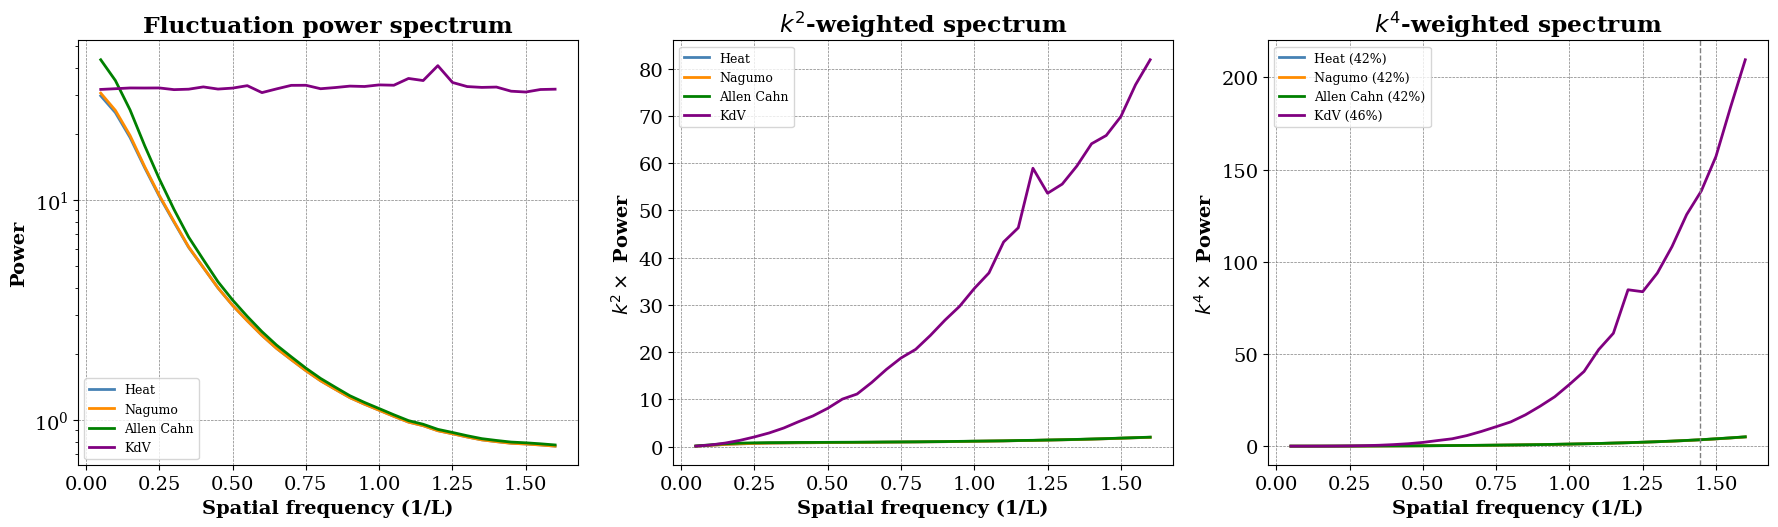

In [71]:
plt.rcParams["font.family"] = "serif"
plt.rcParams['font.size'] = 14
colors = {'Heat': 'steelblue', 'Nagumo': 'darkorange', 'Allen_Cahn': 'green', 'KdV': 'purple'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

top_decile_shares = {}

if DO_SMOOTHNESS_ANALYSIS:
    for problem in experimentKeys:
        if not experimentKeys[problem] or problem == "Burgers":
            continue

        U = np.load(f'data/{problem}_dx_{spacePoints}m_{timeSteps}t.npy')
        dx = space / U.shape[0]

        U_mean = np.mean(U, axis=2, keepdims=True)
        R = U - U_mean

        fft_vals = np.fft.rfft(R, axis=0)
        power = np.mean(np.abs(fft_vals)**2, axis=(1, 2))
        freqs = np.fft.rfftfreq(U.shape[0], d=dx)
        k = freqs

        weighted_k2 = power * k**2
        weighted_k4 = power * k**4

        k_nonzero = k[1:]
        w4_nonzero = weighted_k4[1:]
        top_decile_cutoff = np.quantile(k_nonzero, 0.9)
        top_decile_share = np.sum(w4_nonzero[k_nonzero >= top_decile_cutoff]) / np.sum(w4_nonzero)
        top_decile_shares[problem] = top_decile_share

        axes[0].semilogy(k[1:], power[1:], color=colors[problem], linewidth=2,
                          label=problem.replace('_', ' '))
        axes[1].plot(k[1:], weighted_k2[1:], color=colors[problem], linewidth=2,
                      label=problem.replace('_', ' '))
        axes[2].plot(k[1:], weighted_k4[1:], color=colors[problem], linewidth=2,
                      label=f"{problem.replace('_', ' ')} ({top_decile_share:.0%})")

    axes[2].axvline(top_decile_cutoff, color='gray', linestyle='--', linewidth=1)

    titles = ['Fluctuation power spectrum', r'$k^2$-weighted spectrum', r'$k^4$-weighted spectrum']
    ylabels = ['Power', r'$k^2 \times$ Power', r'$k^4 \times$ Power']
    for ax, title, ylabel in zip(axes, titles, ylabels):
        ax.set_xlabel('Spatial frequency (1/L)', fontweight='bold')
        ax.set_ylabel(ylabel, fontweight='bold')
        ax.set_title(title, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(color='gray', linestyle='--', linewidth=0.5)

    plt.tight_layout()
    plt.savefig('worthwhileImages/fourier_smoothness_combined.pdf', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
    # per-trajectory correlation: u_xx vs u_xxxx
    # for each trajectory separately, compute correlation across space and time

if DO_UXX_UXXXX_CORR:
    for key, value in experimentKeys.items():
        if not value or key == "Burgers":
            continue
        U = np.load(f'data/{key}_dx_{spacePoints}m_{timeSteps}t.npy')
        N = U.shape[0]
        dx = space / U.shape[0]
        per_traj_corrs = []

        for sample in range(U.shape[2]):
            u_traj = U[:, :-1, sample]  # shape (64, 500)
            
            u_xx_traj = np.zeros_like(u_traj)
            u_xxxx_traj = np.zeros_like(u_traj)
            
            for t in range(u_traj.shape[1]):
                u_xx_traj[:, t] = SPDE.FiniteDiff(u_traj[:, t], dx, 2, periodic=True)
                u_xxxx_traj[:, t] = SPDE.FiniteDiff(u_traj[:, t], dx, 4, periodic=True) # just checking, but will probably have to regenerate data with more accurate stencils
            
            corr = np.corrcoef(u_xx_traj.flatten(), u_xxxx_traj.flatten())[0,1]
            per_traj_corrs.append(corr)

        per_traj_corrs = np.array(per_traj_corrs)

        print(f"Per-trajectory correlation u_xx vs u_xxxx:")
        print(f"  Mean: {np.mean(per_traj_corrs):.4f}")
        print(f"  Std:  {np.std(per_traj_corrs):.4f}")
        print(f"  Min:  {np.min(per_traj_corrs):.4f}")
        print(f"  Max:  {np.max(per_traj_corrs):.4f}")

        plt.figure(figsize=(8, 4))
        plt.hist(per_traj_corrs, bins=50)
        plt.xlabel('Per-trajectory correlation (u_xx vs u_xxxx)')
        plt.ylabel('Count')
        plt.title(f'Distribution of per-trajectory correlations - {key}')
        plt.axvline(np.mean(per_traj_corrs), color='red', linestyle='--', label=f'Mean={np.mean(per_traj_corrs):.3f}')
        plt.legend()
        plt.tight_layout()
        plt.savefig(f'worthwhileImages/per_traj_corr_{key.lower()}.pdf', dpi=150, bbox_inches='tight')
        plt.show()

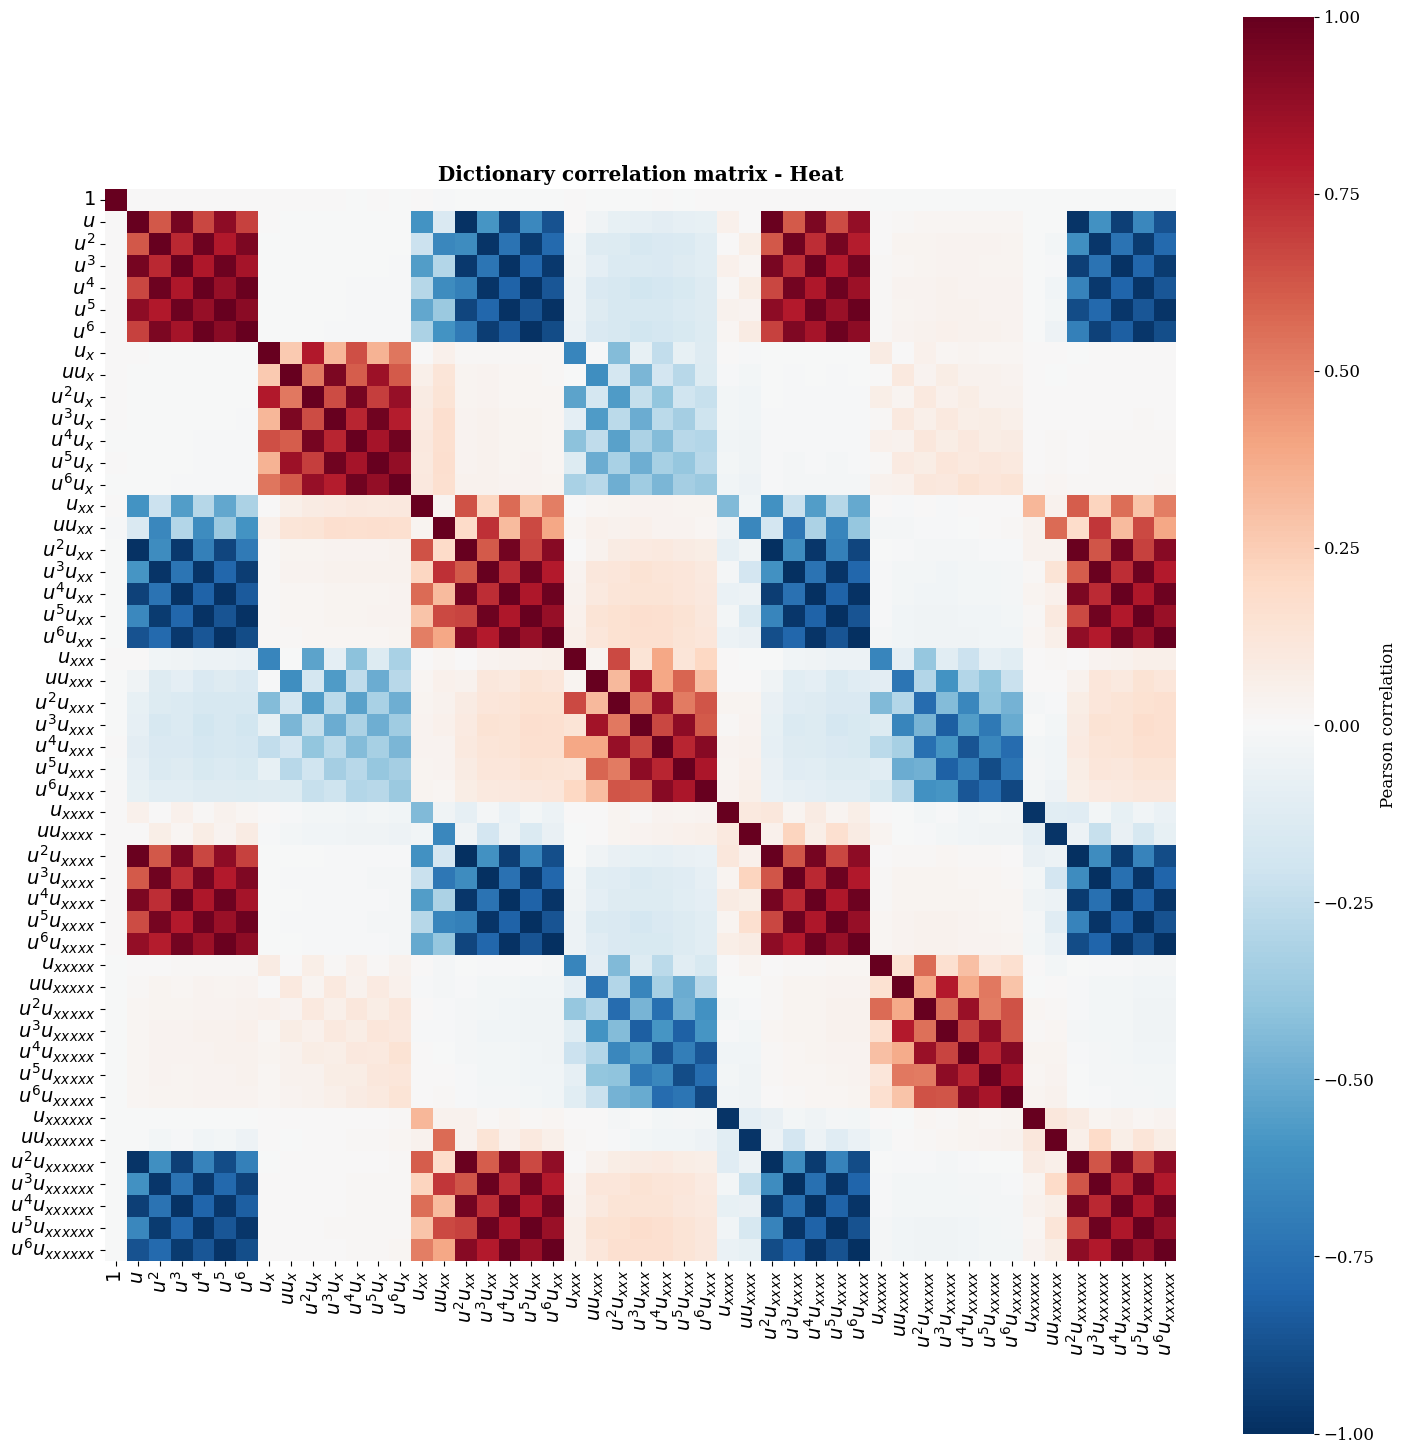

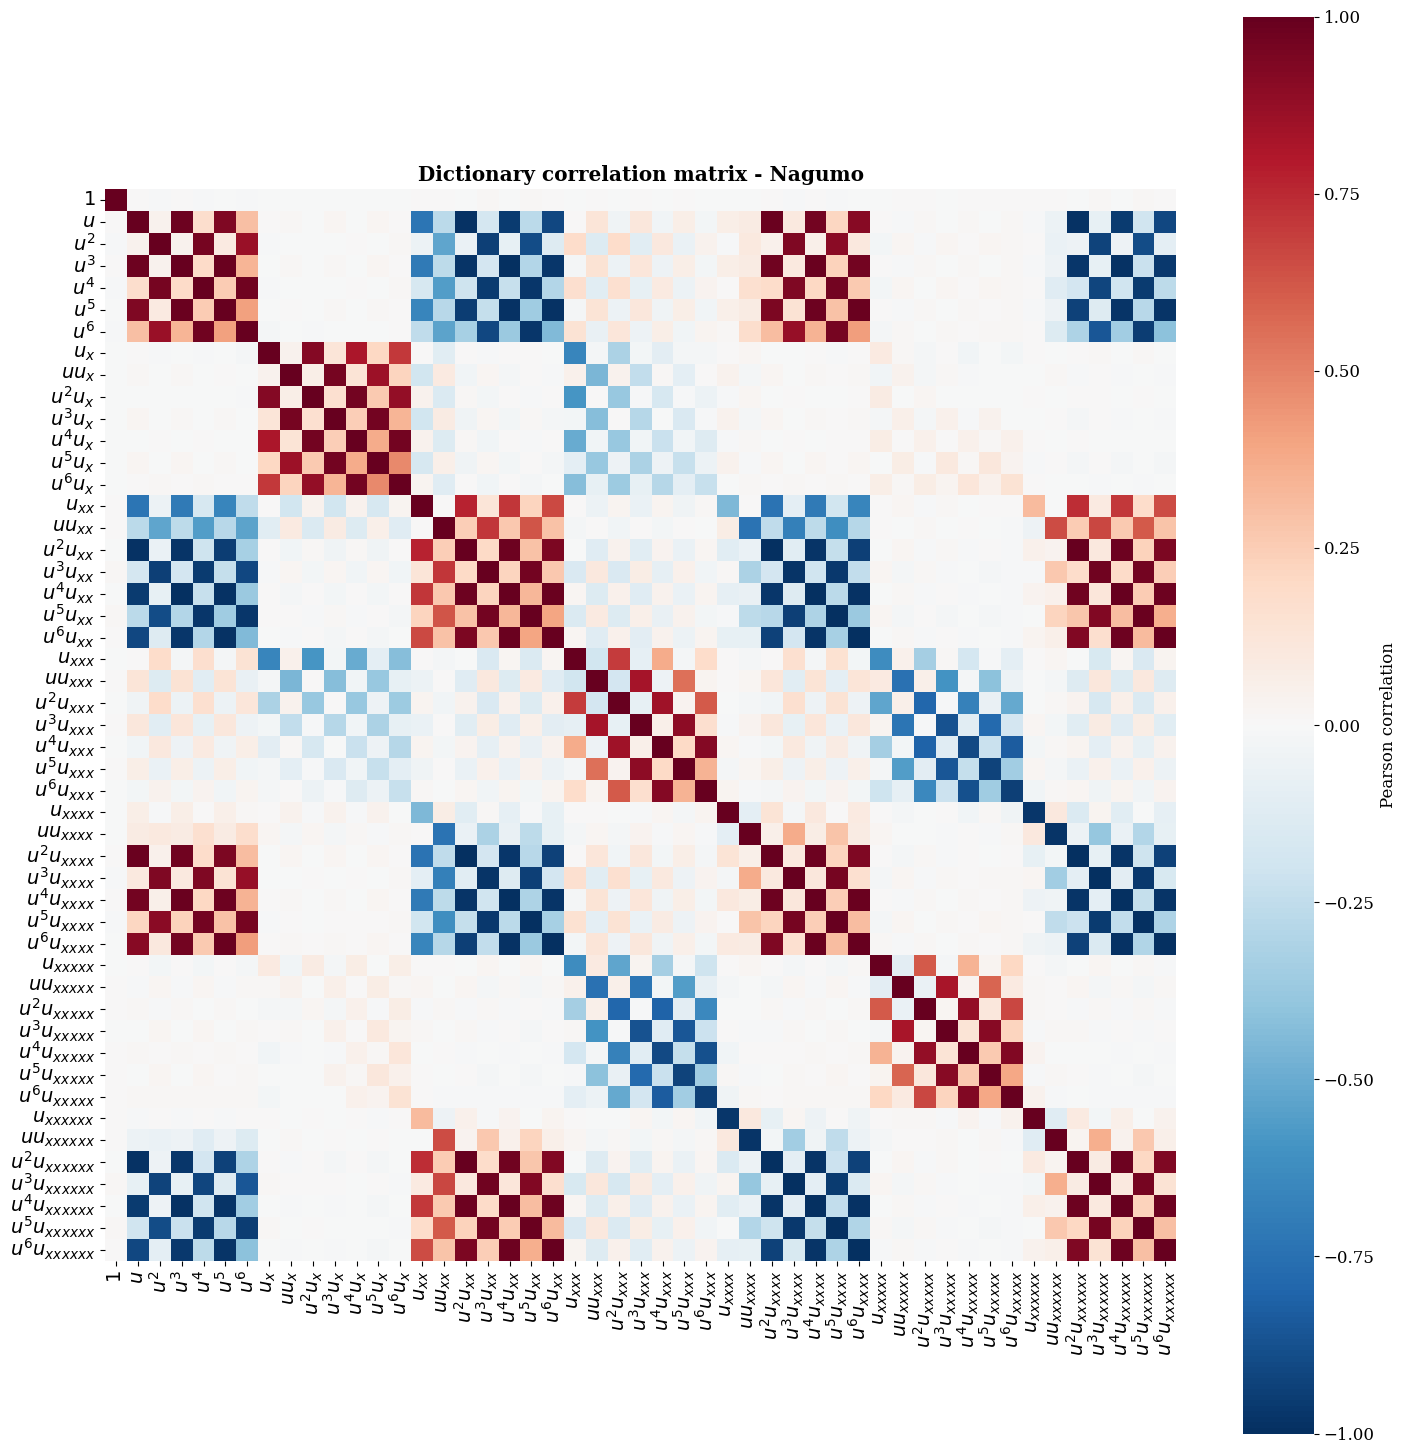

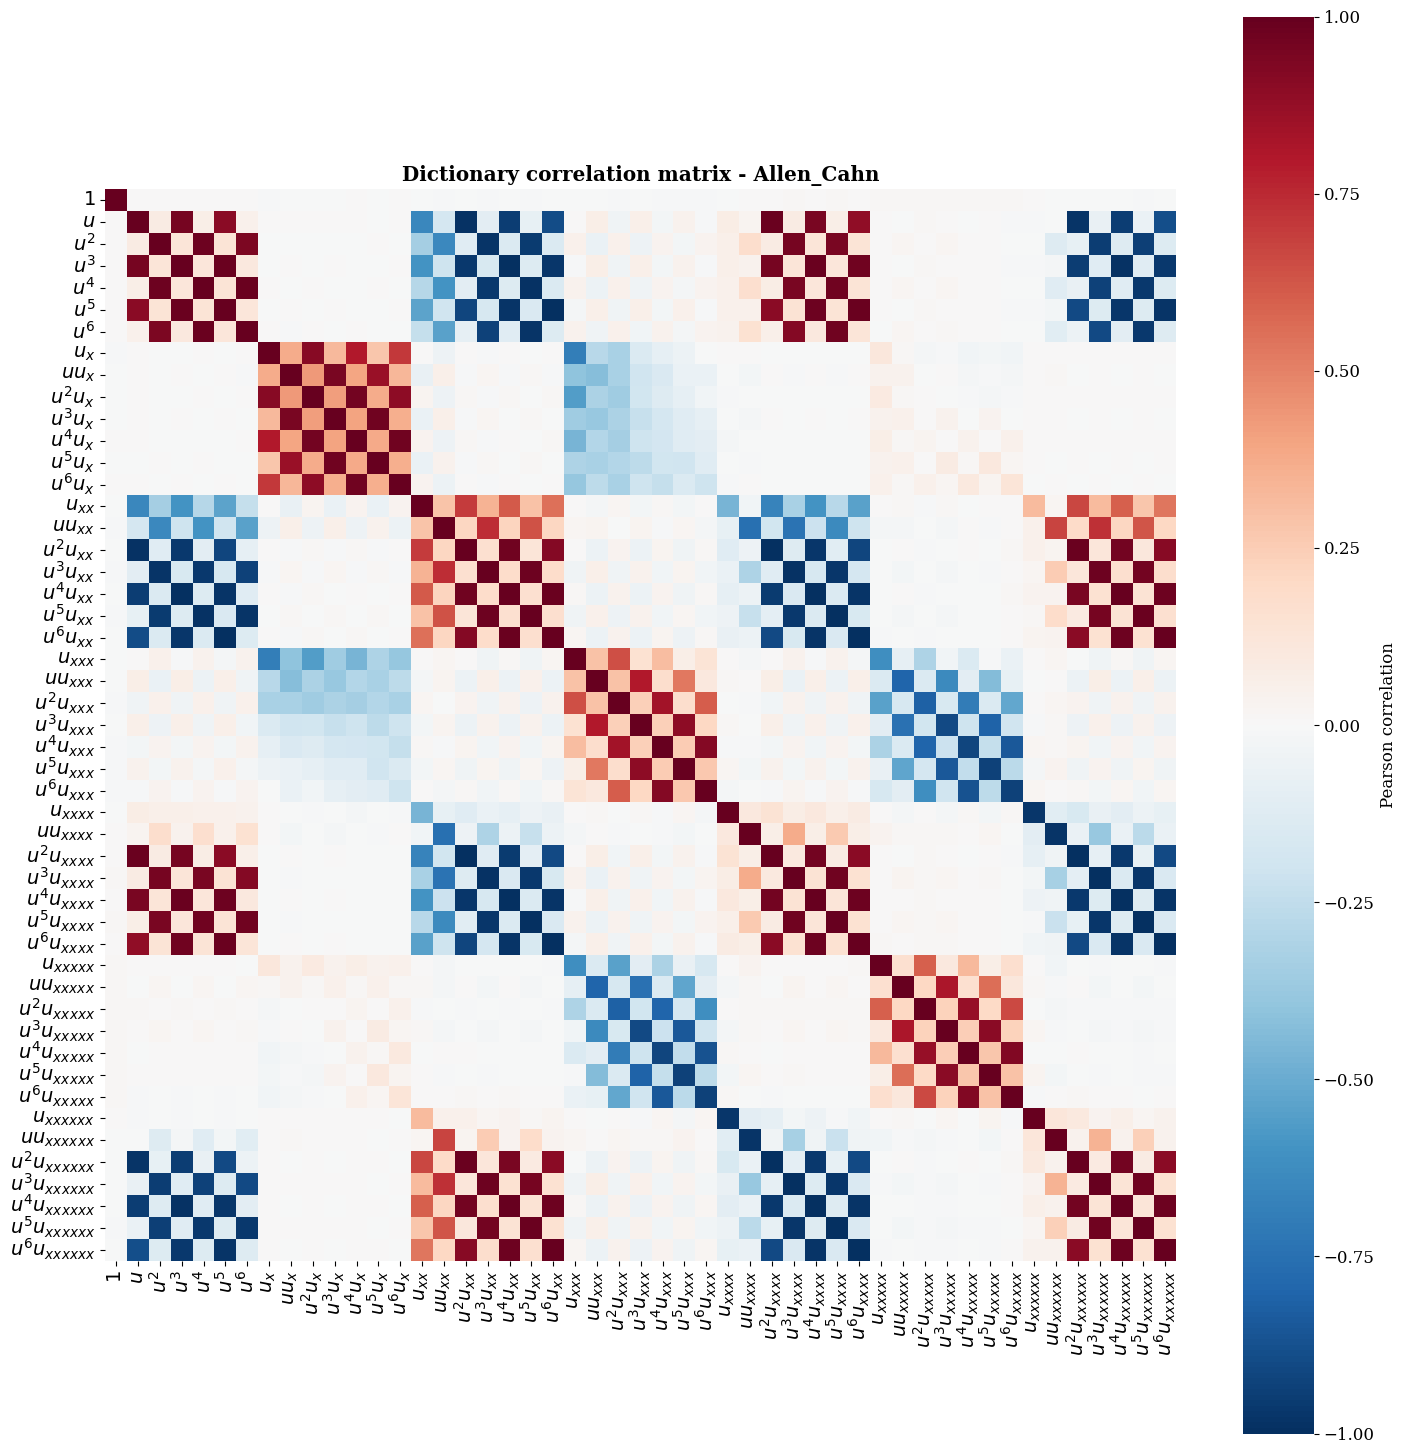

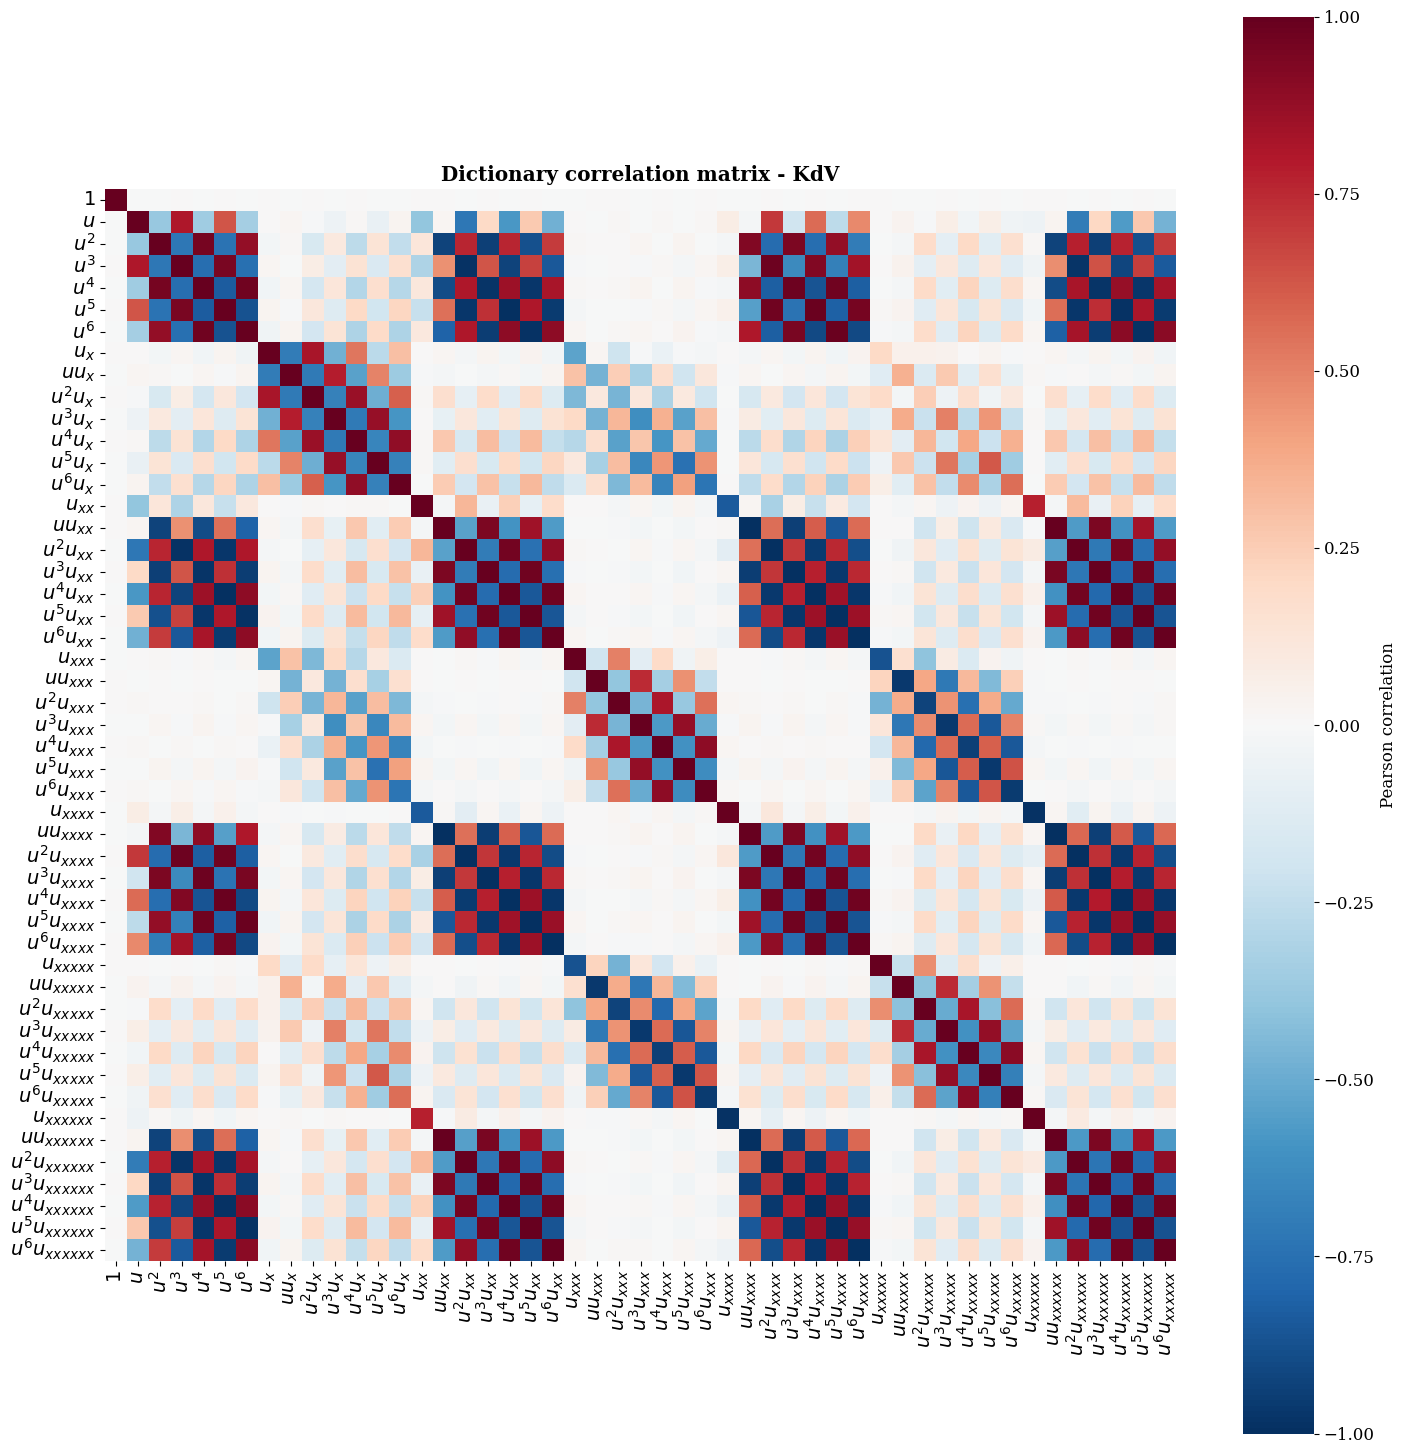

In [ ]:
import seaborn as sns
import re

plt.rcParams['font.size'] = 12

if DO_HEATMAPS:
    for problem in experimentKeys:
        if not experimentKeys[problem] or problem == "Burgers":
            continue

        desc = problemDescriptions[problem]
        dictionary = problemDictionaries[problem]
        corr = np.corrcoef(dictionary.T)

        labels = [f'${d}$' if d != '' else '1' for d in desc]
        labels = [
            f"${re.sub(r'([xX]+)', r'{\1}', d)}$" if d != '' else '1' 
            for d in desc
        ]

        fig, ax = plt.subplots(figsize=(max(8, 0.3 * len(desc)), max(8, 0.3 * len(desc))))
        sns.heatmap(
            corr,
            ax=ax,
            cmap='RdBu_r',
            vmin=-1, vmax=1,
            xticklabels=labels,
            yticklabels=labels,
            square=True,
            cbar_kws={'label': 'Pearson correlation'},
        )

        ax.set_title(f'Dictionary correlation matrix - {problem}', fontweight='bold')
        ax.tick_params(axis='x', labelrotation=90, labelsize=14)
        ax.tick_params(axis='y', labelrotation=0, labelsize=14)

        plt.tight_layout()
        plt.savefig(f'worthwhileImages/corr_heatmap_{problem.lower()}.pdf', dpi=150, bbox_inches='tight')
        plt.show()

In [ ]:
if DO_TEMPORAL_CORR_DIAGNOSTIC:
    for key, value in experimentKeys.items():
        if not value or key == "Burgers":
            continue

        u = np.load(f'data/{key}_dx_{spacePoints}m_{timeSteps}t.npy')  # (N, T, samples)
        n = u.shape[0]
        dx = space / n

        uFull = u[:, :-1, :]                      # (N, T, samples)
        uMeanTraj = uFull.mean(axis=2)            # ensemble mean field, (N, T)
        tSteps = uFull.shape[1]

        def derivPerTimestep(traj, derivativeOrder):
            out = np.zeros_like(traj)
            for t in range(traj.shape[1]):
                out[:, t] = SPDE.FiniteDiff(
                    traj[:, t],
                    dx,
                    derivativeOrder,
                    periodic=True
                )
            return out

        # --- Check #1: per-timestep spatial-only correlation rho(t) ---
        nSampleTrajs = uFull.shape[2]
        rhoTraj = np.zeros((nSampleTrajs, tSteps))

        for sampleIdx in range(nSampleTrajs):
            uxxSample = derivPerTimestep(uFull[:, :, sampleIdx], 2)
            uxxxxSample = derivPerTimestep(uFull[:, :, sampleIdx], 4)

            for t in range(tSteps):
                rhoTraj[sampleIdx, t] = np.corrcoef(
                    uxxSample[:, t],
                    uxxxxSample[:, t]
                )[0, 1]

        uxxMean = derivPerTimestep(uMeanTraj, 2)
        uxxxxMean = derivPerTimestep(uMeanTraj, 4)

        rhoMean = np.array([
            np.corrcoef(uxxMean[:, t], uxxxxMean[:, t])[0, 1]
            for t in range(tSteps)
        ])

        plt.figure(figsize=(9, 4))

        for sampleIdx in range(nSampleTrajs):
            plt.plot(
                rhoTraj[sampleIdx],
                color='steelblue',
                alpha=0.25
            )  # see 3rd line - but not meaned (for every sample)

        plt.plot(
            rhoMean,
            color='red',
            linewidth=2,
            label='ensemble-mean solution'
        )  # average solutions over all samples, then correlations of these

        plt.plot(
            rhoTraj.mean(axis=0),
            color='black',
            linewidth=2,
            linestyle='--',
            label='mean of per-solution $\\rho(t)$'
        )  # correlations of each solution per time, then mean of these

        plt.xlabel('Timestep')
        plt.ylabel(r'$\rho(t)$: spatial corr($u_{xx}$, $u_{xxxx}$) at fixed $t$')
        plt.title(f'{key}: per-timestep correlation, solutions vs. mean solution')
        plt.legend()
        plt.grid(color='gray', linestyle='--', linewidth=0.5)
        plt.tight_layout()
        plt.savefig(
            f'worthwhileImages/rho_t_{key.lower()}.pdf',
            dpi=150,
            bbox_inches='tight'
        )
        plt.show()

        # --- Check #2: demeaned (fluctuation-only) correlation ---
        fluctCorrs = []

        for sampleIdx in range(nSampleTrajs):
            fluct = uFull[:, :, sampleIdx] - uMeanTraj  # this solution's noise component

            uxxFluct = derivPerTimestep(fluct, 2)
            uxxxxFluct = derivPerTimestep(fluct, 4)

            fluctCorrs.append(
                np.corrcoef(
                    uxxFluct.flatten(),
                    uxxxxFluct.flatten()
                )[0, 1]
            )

        fluctCorrs = np.array(fluctCorrs)

        print(f"\n=== {key} ===")
        print(
            f"Mean-solution correlation (flattened space-time): "
            f"{np.corrcoef(uxxMean.flatten(), uxxxxMean.flatten())[0, 1]:.4f}"
        )
        print(
            f"Per-solution full-field correlation: "
            f"mean={rhoTraj.mean():.4f}"
        )
        print(
            f"Per-solution FLUCTUATION-ONLY correlation: "
            f"mean={fluctCorrs.mean():.4f}, std={fluctCorrs.std():.4f}"
        )

# Prediction

Generate data per discovered coefficients

correct sample: 0
correct sample: 50
correct sample: 100
correct sample: 150
correct shape: (64, 501, 200)
pred sample: 0
pred sample: 50
pred sample: 100
pred sample: 150
pred shape: (64, 501, 200)


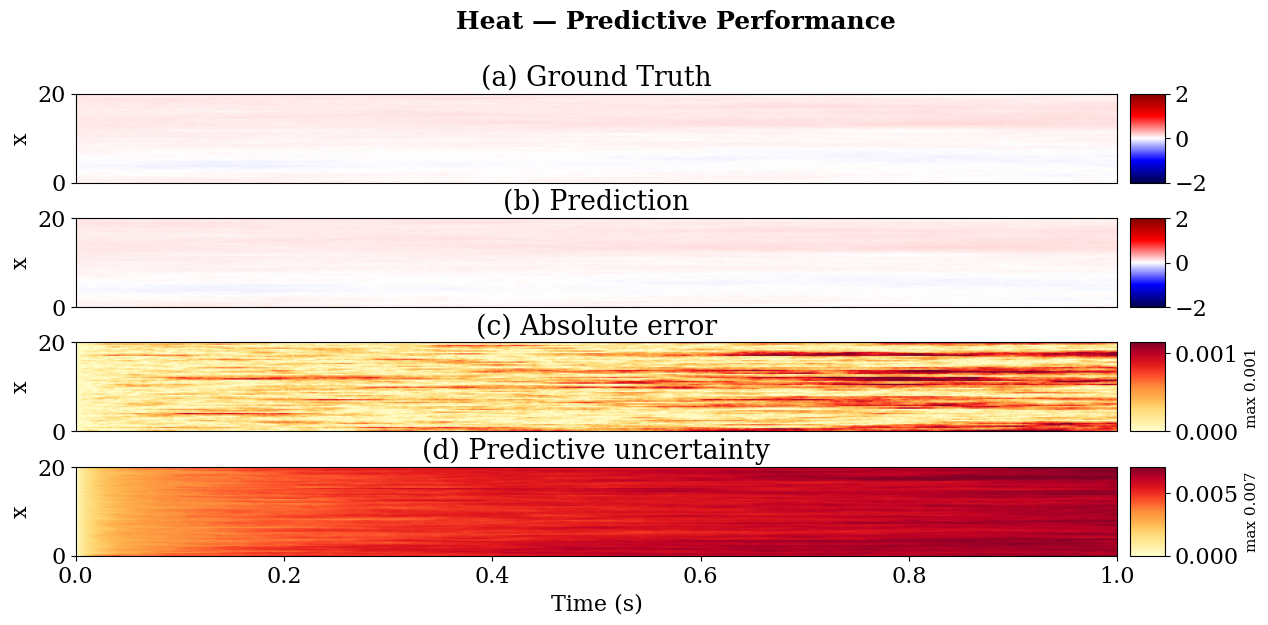

correct sample: 0
correct sample: 50
correct sample: 100
correct sample: 150
correct shape: (64, 501, 200)
pred sample: 0
pred sample: 50
pred sample: 100
pred sample: 150
pred shape: (64, 501, 200)


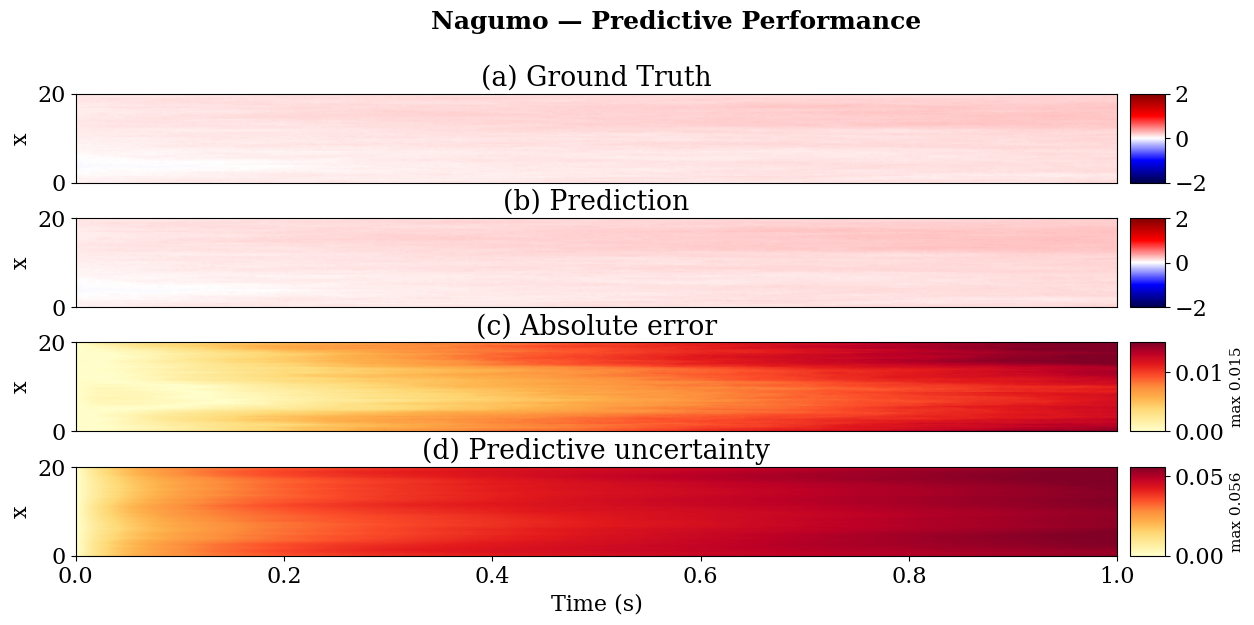

correct sample: 0
correct sample: 50
correct sample: 100
correct sample: 150
correct shape: (64, 501, 200)
pred sample: 0
pred sample: 50
pred sample: 100
pred sample: 150
pred shape: (64, 501, 200)


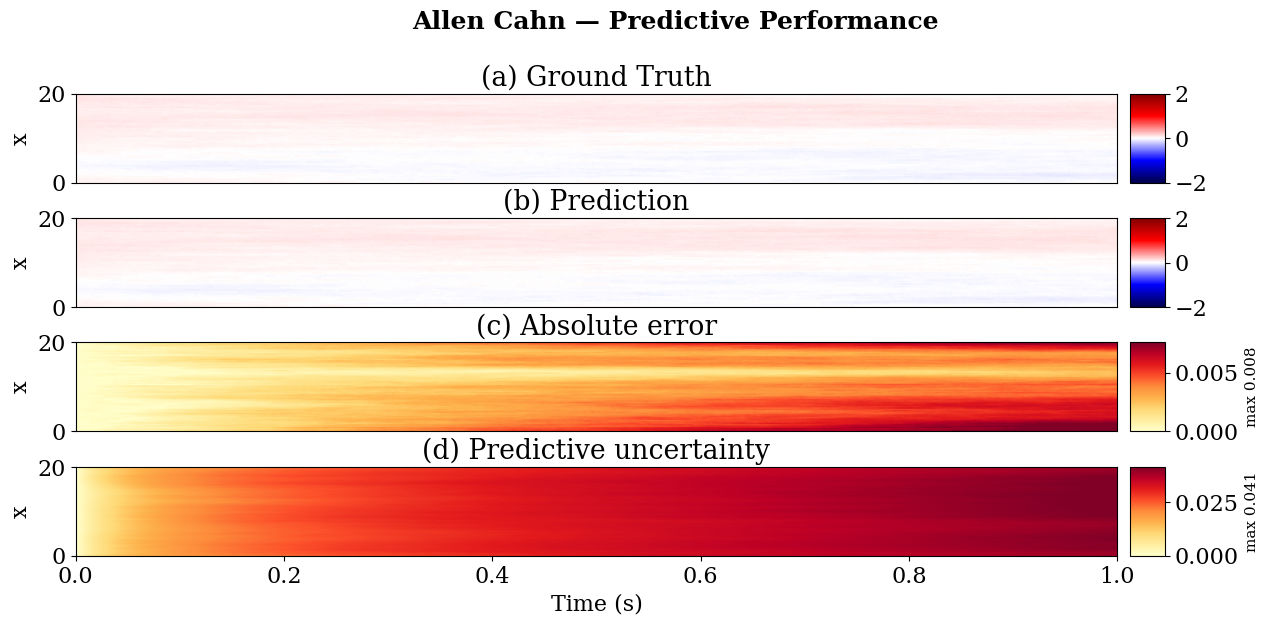

correct sample: 0
correct sample: 50
correct sample: 100
correct sample: 150
correct shape: (64, 501, 200)
pred sample: 0
pred sample: 50
pred sample: 100
pred sample: 150
pred shape: (64, 501, 200)


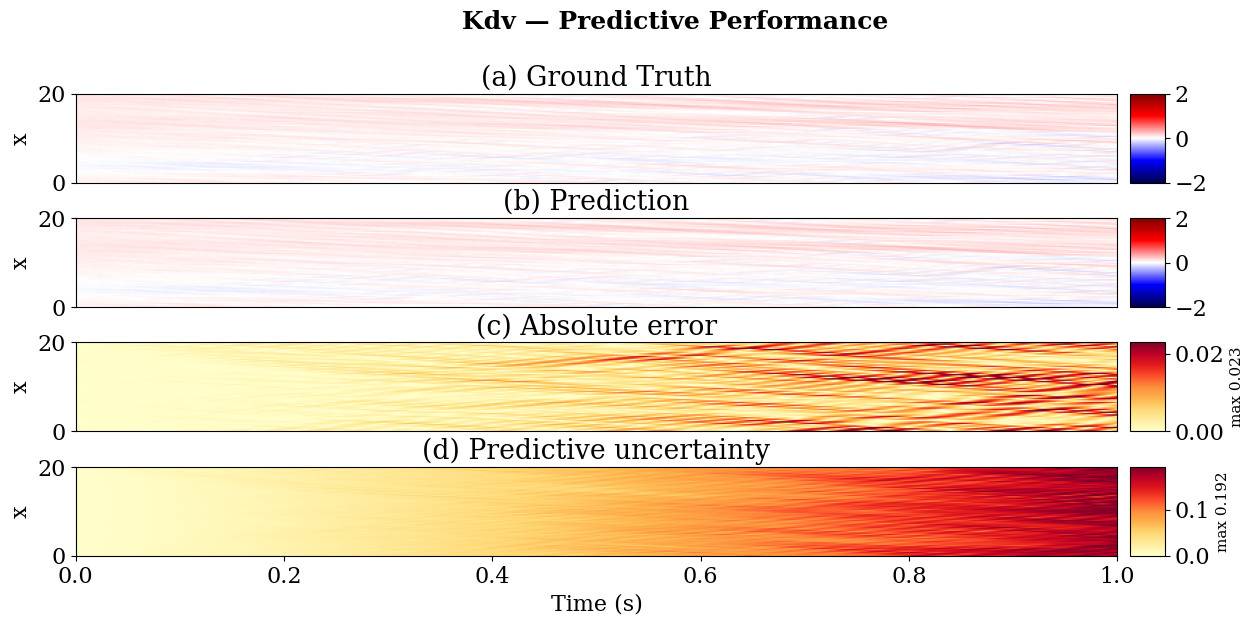

In [75]:
import PredictionDataGenerator

with open("parameters.yaml") as f:
    yamlParameters = yaml.safe_load(f)
for key, value in experimentKeys.items():
    if value and not key == "Burgers":
        if GENERATE_PREDICTION_DATA:
            PredictionDataGenerator.generatePrediction(key)
        
        U3 = np.load(f'data/{key}_prediction_correct.npy')
        U4 = np.load(f'data/{key}_prediction_pred.npy')
        plt.rcParams['font.size'] = 16

        uu  = np.mean(U3, axis=2)
        uu1 = np.mean(U4, axis=2)
        err = np.abs(uu - uu1)
        unc = np.std(U3 - U4, axis=2)

        # per-problem scales — 99th percentile avoids outlier blow-up
        err_vmax = np.percentile(err, 99)
        unc_vmax = np.percentile(unc, 99)

        fig = plt.figure(figsize=(16, 6))
        fig.subplots_adjust(wspace=1, hspace=0.4)
        solution_cmap = 'seismic'
        error_cmap    = 'YlOrRd'

        plt.subplot(4, 1, 1)
        plt.imshow(uu, cmap=solution_cmap, aspect='auto', origin='lower',
                   extent=[0, 1, 0, 20], vmin=-2, vmax=2)
        plt.ylabel('x'); plt.title('(a) Ground Truth'); plt.xticks([], [])
        plt.colorbar(aspect=2.5, pad=0.01)

        plt.subplot(4, 1, 2)
        plt.imshow(uu1, cmap=solution_cmap, aspect='auto', origin='lower',
                   extent=[0, 1, 0, 20], vmin=-2, vmax=2)
        plt.ylabel('x'); plt.title('(b) Prediction'); plt.xticks([], [])
        plt.colorbar(aspect=2.5, pad=0.01)

        plt.subplot(4, 1, 3)
        plt.imshow(err, cmap=error_cmap, aspect='auto', origin='lower',
                   extent=[0, 1, 0, 20], vmin=0, vmax=err_vmax)
        plt.ylabel('x'); plt.title('(c) Absolute error'); plt.xticks([], [])
        cb = plt.colorbar(aspect=2.5, pad=0.01)
        cb.set_label(f'max {err_vmax:.3f}', fontsize=11)

        plt.subplot(4, 1, 4)
        plt.imshow(unc, cmap=error_cmap, aspect='auto', origin='lower',
                   extent=[0, 1, 0, 20], vmin=0, vmax=unc_vmax)
        plt.xlabel('Time (s)'); plt.ylabel('x')
        plt.title('(d) Predictive uncertainty')
        cb = plt.colorbar(aspect=2.5, pad=0.01)
        cb.set_label(f'max {unc_vmax:.3f}', fontsize=11)

        fig.suptitle(f'{key.replace("_", " ").title()} — Predictive Performance',
                     fontweight='bold', fontsize=18, y=1.02)
        plt.show()
        fig.savefig(f'worthwhileImages/{key}_prediction.pdf', format='pdf',
                    dpi=300, bbox_inches='tight')